In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import DataLoader
from torchvision import datasets , transforms  
import matplotlib.pyplot as plt
import cv2
import random
from pathlib import Path


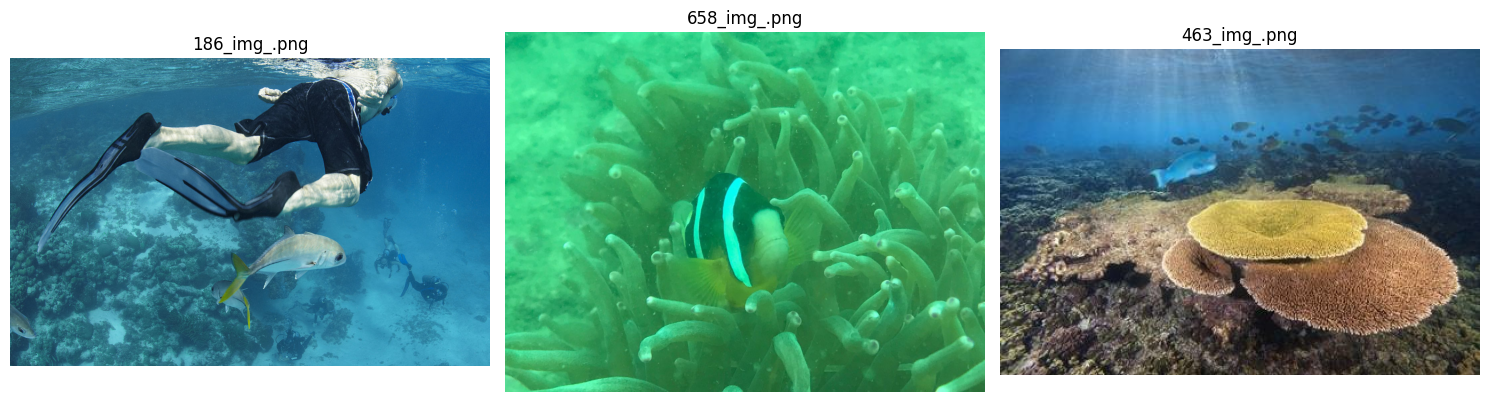

In [18]:


image_path = Path("./raw-890/")
image_path_list = list(image_path.glob("*.png"))


def select_randomly_and_plot_transformed_images(image_paths, transform=None, n=3, seed=None):
    if len(image_paths) == 0:
        print("No images found.")
        return

    if seed is not None:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))


    for ax, image_path in zip(axes, random_image_paths):
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if transform is not None:
            img = transform(img)

        ax.imshow(img)
        ax.set_title(image_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    return random_image_paths

image_paths = select_randomly_and_plot_transformed_images(image_paths=image_path_list, transform=None, n=3, seed=None)

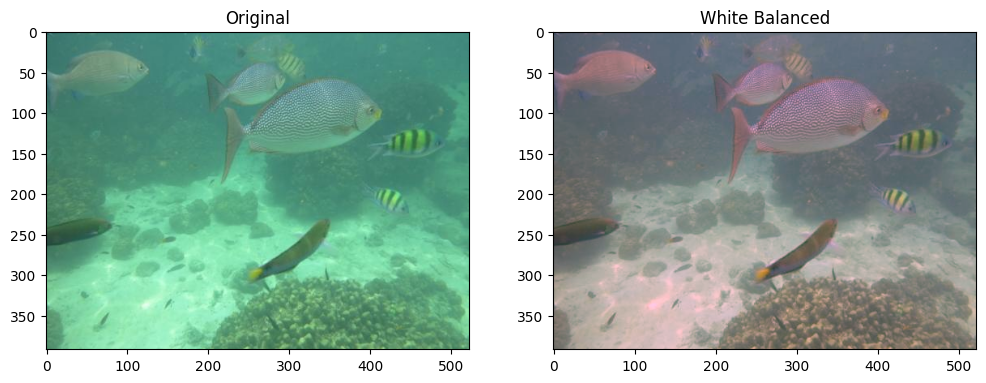

In [19]:
# image = cv2.imread('raw-890/348_img_.png')

random_image_path = random.sample(image_path_list, k=1)
image = cv2.imread(str(random_image_path[0]))
init = image

def gray_world_white_balance(img: np.ndarray, max_gain: float = 1.8) -> np.ndarray:
    """Gray-world white balance with gain capping. Without the cap, a channel
    with a very low mean (typically red, underwater) gets a huge scale factor
    and blows out into a color cast - capping keeps corrections plausible."""
    img_float = img.astype(np.float32)
    b, g, r = cv2.split(img_float)
    mean_b, mean_g, mean_r = np.mean(b), np.mean(g), np.mean(r)
    mean_gray = (mean_b + mean_g + mean_r) / 3.0
    scale_b = np.clip(mean_gray / (mean_b + 1e-5), 1 / max_gain, max_gain)
    scale_g = np.clip(mean_gray / (mean_g + 1e-5), 1 / max_gain, max_gain)
    scale_r = np.clip(mean_gray / (mean_r + 1e-5), 1 / max_gain, max_gain)
    b, g, r = b * scale_b, g * scale_g, r * scale_r
    balanced = cv2.merge([np.clip(c, 0, 255) for c in (b, g, r)])
    return balanced.astype(np.uint8)
# def gray_world_white_balance(img):
    
#     img_float = img.astype(np.float32)
    

#     b, g, r = cv2.split(img_float)
    
 
#     mean_b = np.mean(b)
#     mean_g = np.mean(g)
#     mean_r = np.mean(r)
    
   
#     mean_gray = (mean_b + mean_g + mean_r) / 3.0
    
  
#     scale_b = mean_gray / (mean_b + 1e-5)
#     scale_g = mean_gray / (mean_g + 1e-5)
#     scale_r = mean_gray / (mean_r + 1e-5)
    

#     b_balanced = b * scale_b
#     g_balanced = g * scale_g
#     r_balanced = r * scale_r
    
  
#     b_balanced = np.clip(b_balanced, 0, 255)
#     g_balanced = np.clip(g_balanced, 0, 255)
#     r_balanced = np.clip(r_balanced, 0, 255)
    

#     balanced_img = cv2.merge([b_balanced, g_balanced, r_balanced])
#     return balanced_img.astype(np.uint8)



if image is not None:
    
    result = gray_world_white_balance(image)
    
plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(122);plt.imshow(result[...,::-1]);plt.title("White Balanced");

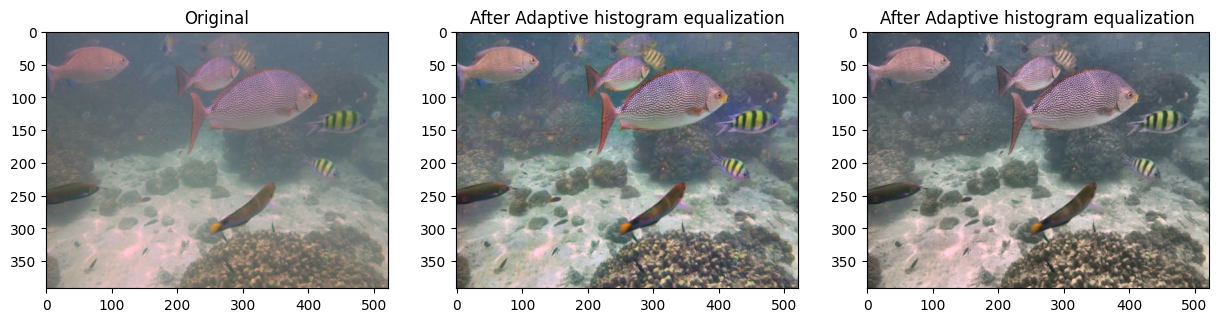

In [20]:
import cv2
import matplotlib.pyplot as plt


###############

image = result 


# Histogram Equalization
channels = cv2.split(image)

#Adaptive method(CLAHE)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
eq_channels = []
for ch in channels:
    eq_channels.append(clahe.apply(ch))
eq_clahe_image = cv2.merge(eq_channels)



lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_eq = clahe.apply(l)
eq_clahe_image2 = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)



#plot images
plt.figure(figsize=[15,15])
plt.subplot(131);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(132);plt.imshow(eq_clahe_image[...,::-1]);plt.title("After Adaptive histogram equalization");
plt.subplot(133);plt.imshow(eq_clahe_image2[...,::-1]);plt.title("After Adaptive histogram equalization");

# color = ('b', 'g', 'r')
# #Original image histogram
# plt.subplot(322);
# for i, col in enumerate(color):
#     histogram = cv2.calcHist([image], [i], None, [256], [0, 256])
#     plt.plot(histogram, color = col)

# #Equualized image histogram with Adaptive method
# plt.subplot(324);
# for i, col in enumerate(color):
#     histogram = cv2.calcHist([eq_clahe_image], [i], None, [256], [0, 256])
#     plt.plot(histogram, color = col)
    
result = eq_clahe_image

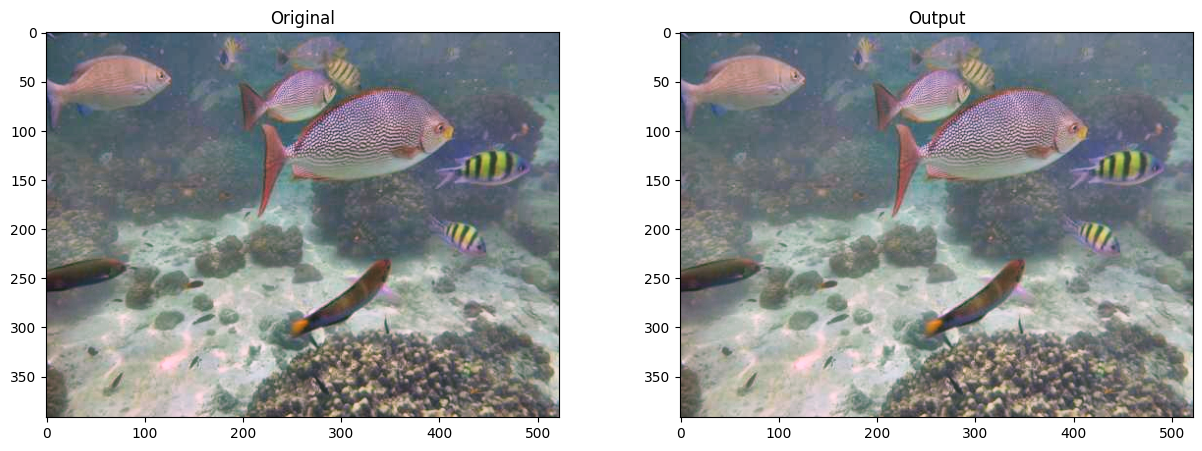

In [21]:
gamma = 0.9

img_original = result

lookUpTable = np.empty((1,256), np.uint8)

for i in range(256):
    lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)
out = cv2.LUT(img_original, lookUpTable)


plt.figure(figsize=[15,5])
plt.subplot(121);plt.imshow(img_original[...,::-1]);plt.title("Original");
plt.subplot(122);plt.imshow(out[...,::-1]);plt.title("Output");



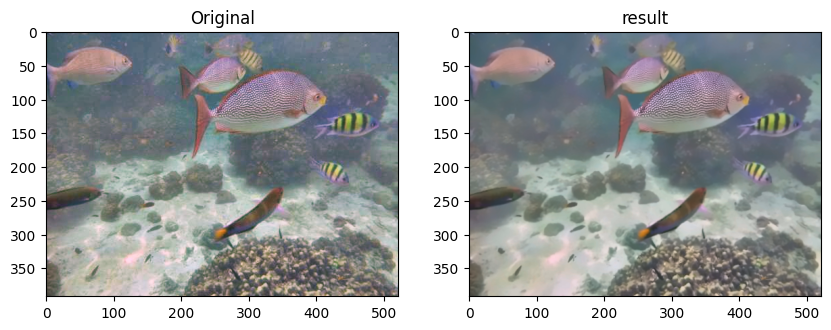

In [22]:
image = out

# Parameters, after None are - the filter strength 'h' (5-10 is a good range)
# Next is hForColorComponents, set as same value as h again
# 

# dst = cv2.bilateralFilter(image, d=5, sigmaColor=75, sigmaSpace=75)

dst = cv2.fastNlMeansDenoisingColored(image, None, h=6, hColor=6, templateWindowSize=3, searchWindowSize=15)


plt.figure(figsize=[10,10])
plt.subplot(221);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(222);plt.imshow(dst[...,::-1]);plt.title("result");

result = dst 

[[-0.11111111 -0.11111111 -0.11111111]
 [-0.11111111  1.88888889 -0.11111111]
 [-0.11111111 -0.11111111 -0.11111111]]


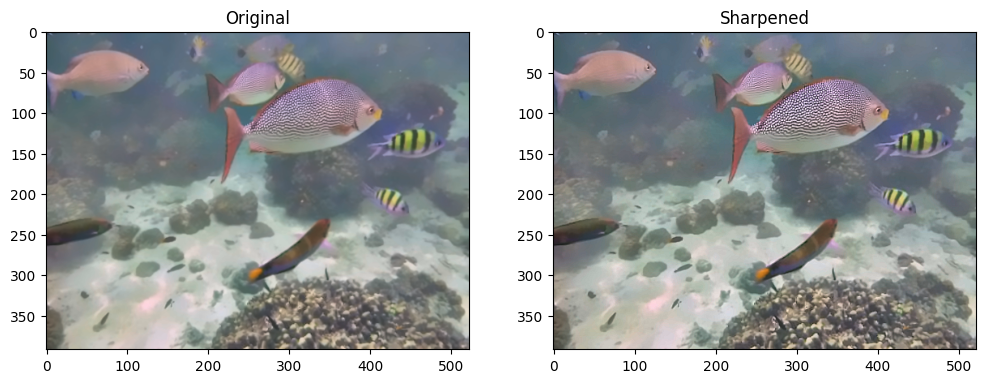

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = result

kernel1 = np.array([[0,0,0], 
                              [0,2,0], 
                              [0,0,0]])

kernel2 = 1/9*np.array([[1,1,1], 
                              [1,1,1], 
                              [1,1,1]])

final_kernel = kernel1-kernel2
# applying different kernels to the input image
sharpened = cv2.filter2D(image, -1, final_kernel)

plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original");
plt.subplot(122);plt.imshow(sharpened[...,::-1]);plt.title("Sharpened");
print(final_kernel)

final = sharpened 

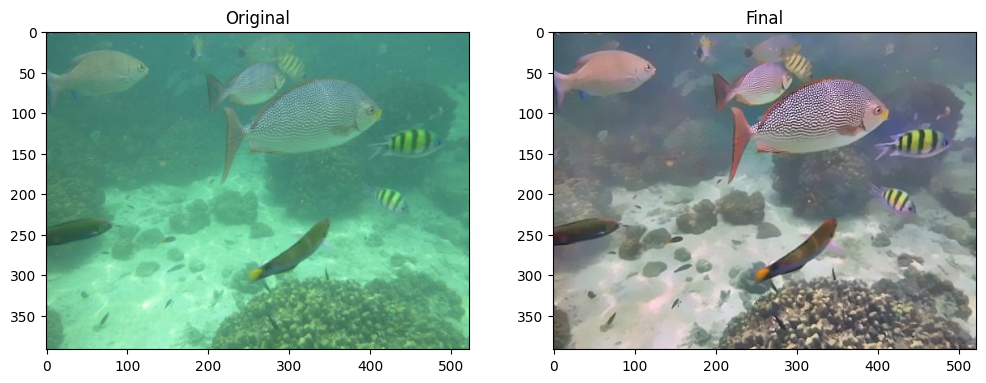

In [24]:
plt.figure(figsize=[12,7])
plt.subplot(121);plt.imshow(init[...,::-1]);plt.title("Original");
plt.subplot(122);plt.imshow(final[...,::-1]);plt.title("Final");